# Differential Equations

We begin with a linear first-order differential equation, typically written as:

:::{math}
:enumerated: false
\dot{x}(t) = \frac{dx(t)}{dt} = a x(t) + b(t)
:::

* The term $a x(t)$ is the **homogeneous part**
* The term $b(t)$ is the **nonhomogeneous part**

:::{admonition} Key Idea
:class: note
A differential equation describes how a variable changes over time. Instead of directly specifying the level of $x(t)$, it specifies the law of motion for $x(t)$.
:::

## Solving First-Order Differential Equations

A solution describes the time path ${x(t)}$ from some initial point $t(0)$ to some future time $t(\tau)$, as a function of:

* time $t$
* the forcing term $b(t)$
* the initial value $x(0)$

:::{admonition} Economic Interpretation
:class: tip
In economics, $x(t)$ could represent capital stock, inflation, debt, money balances, inventories, or adjustment toward equilibrium in a market. The differential equation tells us how quickly and in what direction the variable moves.
:::

### Case: Constant $b$

Consider:

:::{math}
:enumerated: false
\dot{x}(t) = a x(t) + b
:::

### Steady State

At steady state:

:::{math}
:enumerated: false
\dot{x}(t) = 0
:::

So:

:::{math}
:enumerated: false
a x + b = 0
\quad \Rightarrow \quad
x^* = -\frac{b}{a}
:::

:::{admonition} Intuition
:class: note
The steady state is the value of $x$ at which the system stops changing. It is the point where the forces pushing $x$ up and down exactly balance.
:::

### Homogeneous Equation

To solve the full equation, we first solve the homogeneous part:

:::{math}
:enumerated: false
\frac{dx(t)}{dt} = a x(t)
:::

The solution is:

:::{math}
:enumerated: false
x(t) = C e^{a t}
:::

### Verification

Differentiate:

:::{math}
:enumerated: false
\frac{dx(t)}{dt} = a C e^{a t} = a x(t)
:::

Verified.

### Definite Solution

Given an initial condition $x(0)$:

:::{math}
:enumerated: false
x(0) = C e^{0} = C
:::

Thus:

:::{math}
:enumerated: false
x(t) = x(0) e^{a t}
:::

## Stability

The behavior of $x(t)$ depends on $a$:

* If $a < 0$:
  $x(t) \to 0$ as $t \to \infty$ (**stable**)

* If $a > 0$:
  $x(t) \to \infty$ or $-\infty$ (**unstable**)

:::{admonition} Common Pitfall
:class: warning
Do not confuse the existence of a steady state with stability. A steady state may exist, but the system may still move away from it if the dynamics are unstable.
:::

## General Solution (Constant Term)

Consider again:

:::{math}
:enumerated: false
\dot{x}(t) = a x(t) + b
:::

A solution takes the form:

:::{math}
:enumerated: false
x(t) = K e^{a t} - \frac{b}{a}
:::

### Definite Solution

Given $x(0)$:

:::{math}
:enumerated: false
x(0) = K - \frac{b}{a}
\quad \Rightarrow \quad
K = x(0) + \frac{b}{a}
:::

Thus:

:::{math}
:enumerated: false
x(t) = \left(x(0) + \frac{b}{a}\right)e^{a t} - \frac{b}{a}
:::

### Special Case

If $x(0) = x^* = -\frac{b}{a}$:

:::{math}
:enumerated: false
x(t) = x^*
\quad \text{for all } t
:::

## Stability Conditions (with Constant Term)

* If $a < 0$:
  system converges to $x^* = -\frac{b}{a}$ (**stable**)

* If $a > 0$:
  system diverges (**unstable**)

:::{admonition} Economic Interpretation
:class: tip
This kind of equation often appears in partial adjustment models. For example, a firm may gradually adjust its actual capital stock, price, or inventory level toward a desired level. Stability means the adjustment process brings the variable closer to equilibrium over time.
:::

---

## Numerical Example (Stable Case)

Consider:

:::{math}
:enumerated: false
\dot{u}(t) = -\frac{1}{2} u(t) + 2
:::

with initial condition:

:::{math}
:enumerated: false
u(0) = 1
:::

### Step 1: Steady State

:::{math}
:enumerated: false
0 = -\frac{1}{2}u + 2
\quad \Rightarrow \quad
u^* = 4
:::

### Step 2: Solution

:::{math}
:enumerated: false
u(t) = \left(u(0) + \frac{2}{1/2}\right)e^{-t/2} - \frac{2}{-1/2}
:::

Simplify:

:::{math}
:enumerated: false
u(t) = -3 e^{-t/2} + 4
:::

### Interpretation

* $u(t) \to 4$ as $t \to \infty$
* Since $a = -\frac{1}{2} < 0$, the system is **stable**

:::{admonition} Economic Interpretation
:class: tip
This is the kind of path we expect when an economic variable adjusts gradually toward a long-run equilibrium. For instance, a stock of inventories, money balances, or capital may move toward its desired level over time.
:::

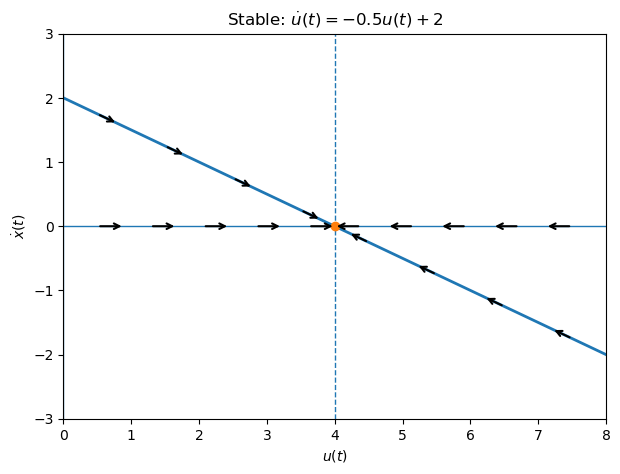

In [13]:
# -----------------------------
# Stable case: u_dot = -0.5u + 2
# -----------------------------
f1 = lambda u: -0.5 * u + 2

# Steady state calculation: 
# -0.5u + 2 = 0  =>  0.5u = 2  =>  u* = 4
phase_diagram(
    f=f1, 
    x_range=(0, 8), 
    x_star=4, 
    title=r'Stable: $\dot{u}(t) = -0.5u(t) + 2$', 
    x_label=r'$u(t)$'
)

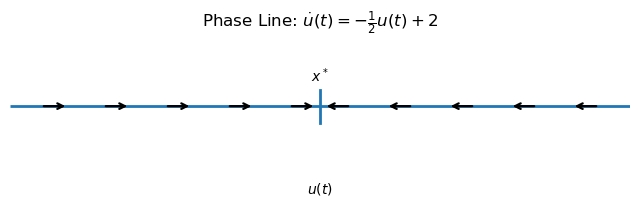

In [14]:
import numpy as np
import matplotlib.pyplot as plt

def draw_phase_line(f, x_range, x_star, x_label=r'$x$', title=''):
    fig, ax = plt.subplots(figsize=(8, 1.8))
    ax.hlines(0, x_range[0], x_range[1], linewidth=2)
    ax.plot([x_star, x_star], [-0.12, 0.12], linewidth=2)
    ax.text(x_star, 0.18, r'$x^*$', ha='center')

    xs = np.linspace(x_range[0] + 0.4, x_range[1] - 0.4, 10)
    for xi in xs:
        if abs(xi - x_star) < 0.2:
            continue
        direction = np.sign(f(xi))
        dx = 0.35 * direction
        ax.annotate(
            '',
            xy=(xi + dx, 0),
            xytext=(xi, 0),
            arrowprops=dict(arrowstyle='->', lw=1.6)
        )

    ax.set_xlim(x_range)
    ax.set_ylim(-0.5, 0.5)
    ax.set_yticks([])
    ax.set_xticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_title(title)
    ax.set_xlabel(x_label)
    plt.show()

f_u = lambda u: -0.5*u + 2
draw_phase_line(
    f=f_u,
    x_range=(0, 8),
    x_star=4,
    x_label=r'$u(t)$',
    title=r'Phase Line: $\dot{u}(t) = -\frac{1}{2}u(t) + 2$'
)

## Numerical Example (Unstable Case)

Consider:

:::{math}
:enumerated: false
\dot{v}(t) = 2 v(t) - 4
:::

with:

:::{math}
:enumerated: false
v(0) = 1
:::

### Step 1: Steady State

:::{math}
:enumerated: false
0 = 2v - 4
\quad \Rightarrow \quad
v^* = 2
:::

### Step 2: Solution

:::{math}
:enumerated: false
v(t) = \left(v(0) - 2\right)e^{2t} + 2
:::

Simplify:

:::{math}
:enumerated: false
v(t) = -e^{2t} + 2
:::

### Interpretation

* As $t \to \infty$, $v(t) \to -\infty$
* Since $a > 0$, the system is **unstable**
* Only if $v(0) = 2$:

:::{math}
:enumerated: false
v(t) = 2 \quad \forall t
:::

:::{admonition} Intuition
:class: note
An unstable steady state behaves like a knife-edge equilibrium. If the system starts exactly there, it remains there. But any small deviation causes it to move away.
:::

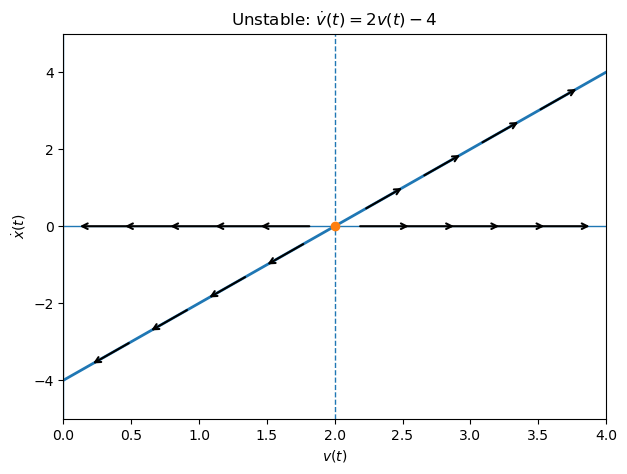

In [8]:
# -----------------------------
# Unstable case: v_dot = 2v - 4
# -----------------------------
f2 = lambda v: 2*v - 4
phase_diagram(
    f=f2,
    x_range=(0, 4),
    x_star=2,
    title=r'Unstable: $\dot{v}(t) = 2v(t) - 4$',
    x_label=r'$v(t)$'
)

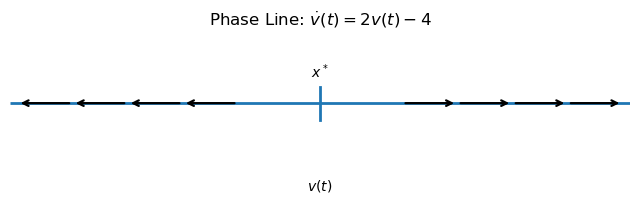

In [16]:
f_v = lambda v: 2*v - 4
draw_phase_line(
    f=f_v,
    x_range=(0, 4),
    x_star=2,
    x_label=r'$v(t)$',
    title=r'Phase Line: $\dot{v}(t) = 2v(t) - 4$'
)

## Solving First-Order Differential Equations by Integration

Let’s start with the homogeneous case

:::{math}
:enumerated: false
\dot{x}(t) = a x(t)
:::

and assuming we know at some point in time $s$ the value $x(s)$.

Rearranging a little and multiplying each side by $ds$ gives

:::{math}
:enumerated: false
\frac{dx(s)}{x(s)} = a , ds
:::

Take the definite integral of both sides evaluated from $0$ to $t$

:::{math}
:enumerated: false
\int_{0}^{t} \frac{1}{x(s)} , dx(s) = \int_{0}^{t} a , ds
:::

and assuming that $x(s) > 0$ gives

:::{math}
:enumerated: false
\ln(x(t)) - \ln(x(0)) = a t - a \cdot 0 = a t
:::

Adding $\ln(x(0))$ to each side and taking exponentials gives

:::{math}
:enumerated: false
e^{\ln(x(t))} = e^{\ln(x(0)) + a t}
:::

Or

:::{math}
:enumerated: false
x(t) = x(0) e^{a t}
:::

(as before).

:::{admonition} Key Idea
:class: note
The integration method reproduces the same solution obtained earlier. Its advantage is that it generalizes naturally to the case with a constant term and then to the case with time-varying forcing term $b(t)$.
:::

## Case with Constant Term

What if we have a constant term as in equation (1) above, also written as

:::{math}
:enumerated: false
\frac{dx(t)}{dt} = a x(t) + b
:::

Consider some moment in time $s$ and multiply each side by $ds$:

:::{math}
:enumerated: false
dx(s) = a x(s) , ds + b , ds
:::

Multiplying again each side by $e^{-as}$ and rearranging gives

:::{math}
:enumerated: false
e^{-as} dx(s) - a x(s)e^{-as} ds = b e^{-as} ds
:::

Looks threatening doesn’t it? Not really. The left-hand side simply reduces to

:::{math}
:enumerated: false
d\big(x(s)e^{-as}\big)
:::

Hence we can write

:::{math}
:enumerated: false
d\big(x(s)e^{-as}\big) = b e^{-as} ds
:::

Taking the definite integral as before

:::{math}
:enumerated: false
\int_{0}^{t} d\big(x(s)e^{-as}\big) = \int_{0}^{t} b e^{-as} ds
:::

### Left-hand side (LHS)

:::{math}
:enumerated: false
x(t)e^{-at} - x(0)
:::

### Right-hand side (RHS)

:::{math}
:enumerated: false
\int_{0}^{t} b e^{-as} ds = \frac{b}{a}\left(1 - e^{-at}\right)
:::

Combining the LHS and RHS gives

:::{math}
:enumerated: false
x(t)e^{-at} - x(0) = \frac{b}{a}\left(1 - e^{-at}\right)
:::

Multiplying each side by $e^{at}$ and rearranging gives

:::{math}
:enumerated: false
x(t) = x(0)e^{at} + \frac{b}{a}\left(e^{at} - 1\right)
:::

Or

:::{math}
:enumerated: false
x(t) = \left(x(0) + \frac{b}{a}\right)e^{at} - \frac{b}{a}
:::

(as before).

:::{admonition} Common Pitfall
:class: warning
A common mistake is to forget that the integrating factor changes the left-hand side into a total derivative. That step is the heart of the method.
:::

---

## More General Case: Time-Varying $b(t)$

What about the more general case when we have $b(t)$ instead of just $b$? That is,

:::{math}
:enumerated: false
\frac{dx(t)}{dt} = a x(t) + b(t)
:::

As before, multiply by $ds$ and $e^{-as}$ to get

:::{math}
:enumerated: false
e^{-as} dx(s) - a x(s)e^{-as} ds = b(s)e^{-as} ds
:::

The treatment of the LHS is the same as before, so we have

:::{math}
:enumerated: false
d\big(x(s)e^{-as}\big) = b(s)e^{-as} ds
:::

Taking integrals gives

:::{math}
:enumerated: false
x(t)e^{-at} - x(0) = \int_{0}^{t} b(s)e^{-as} ds
:::

Multiplying each side by $e^{at}$ and rearranging gives

:::{math}
:enumerated: false
x(t) = x(0)e^{at} + \int_{0}^{t} b(s)e^{a(t-s)} ds
:::

This is known as the **backward solution**, because $x(t)$ depends on past and present values of $b(s)$.

## Interpretation

* The term

  :::{math}
  :enumerated: false
  x(0)e^{at}
  :::

  captures the effect of the initial value over time.

* The term

  :::{math}
  :enumerated: false
  \int_{0}^{t} b(s)e^{a(t-s)} ds
  :::

  reflects the discounted accumulation of past values of $b(s)$.

* If $a < 0$, the effect of the initial value dies out over time.

* If $a > 0$, the initial value grows over time.

:::{admonition} Economic Interpretation
:class: tip
This form is useful when a variable responds not only to its current state but also to a stream of past shocks or policy interventions. The exponential term shows that older shocks typically have less influence than more recent ones when $a < 0$.
:::

## Infinite Horizon Case

When the relevant period extends infinitely into the past and $a < 0$, and assuming $b(s)$ is bounded:

:::{math}
:enumerated: false
x(t) = \int_{-\infty}^{t} b(s)e^{a(t-s)} ds
:::

## Forward Solution

Although not derived here, the forward solution is

:::{math}
:enumerated: false
x(t) = - \int_{t}^{\infty} b(s)e^{-a(s-t)} ds
:::

---

## Economic Example: A Solow-Style Interpretation

A simple capital accumulation equation can be written as

:::{math}
:enumerated: false
\dot{k}(t) = s f(k(t)) - \delta k(t)
:::

where:

* $k(t)$ is capital per worker
* $s f(k(t))$ is saving or investment per worker
* $\delta k(t)$ is depreciation

If we consider a very simple linear case, say $f(k)=k$, then we get

:::{math}
:enumerated: false
\dot{k}(t) = (s-\delta)k(t)
:::

which has the solution

:::{math}
:enumerated: false
k(t) = k(0)e^{(s-\delta)t}
:::

This is exactly of the same form as the homogeneous first-order differential equation studied above.

* If $s-\delta < 0$, capital declines over time
* If $s-\delta > 0$, capital grows over time
* If $s-\delta = 0$, capital remains constant

:::{admonition} Intuition
:class: note
The economics is simple: if saving is greater than depreciation, the capital stock grows. If depreciation dominates saving, the capital stock shrinks.
:::

A more realistic Solow-style specification uses diminishing returns:

:::{math}
:enumerated: false
\dot{k}(t) = s k(t)^\alpha - \delta k(t),
\qquad 0 < \alpha < 1
:::

The steady state satisfies

:::{math}
:enumerated: false
s k^\alpha = \delta k
:::

or equivalently

:::{math}
:enumerated: false
k^* = \left(\frac{s}{\delta}\right)^{\frac{1}{1-\alpha}}
:::

This gives a useful example of a nonlinear differential equation for which phase diagrams are especially helpful.

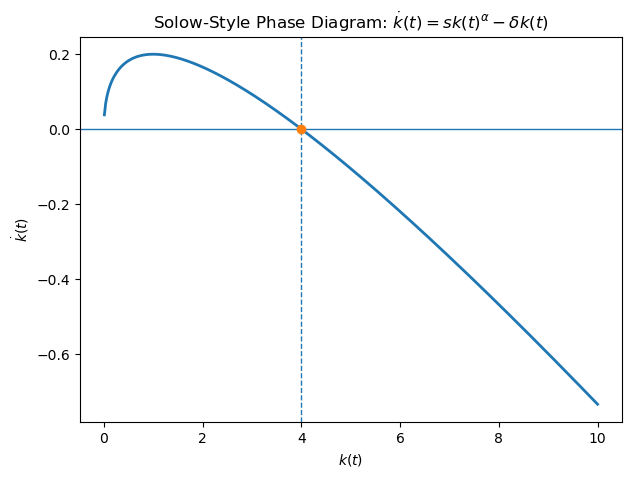

In [17]:
import numpy as np
import matplotlib.pyplot as plt

s = 0.4
alpha = 0.5
delta = 0.2

def kdot(k):
    return s * k**alpha - delta * k

k = np.linspace(0.01, 10, 400)
kd = kdot(k)
k_star = (s / delta)**(1 / (1 - alpha))

plt.figure(figsize=(7, 5))
plt.plot(k, kd, linewidth=2)
plt.axhline(0, linewidth=1)
plt.axvline(k_star, linestyle='--', linewidth=1)
plt.plot(k_star, 0, 'o')
plt.xlabel(r'$k(t)$')
plt.ylabel(r'$\dot{k}(t)$')
plt.title(r'Solow-Style Phase Diagram: $\dot{k}(t)=s k(t)^\alpha - \delta k(t)$')
plt.show()

## Second-Order Differential Equations

The second-order differential equation we will consider in this section is often written as

:::{math}
:enumerated: false
\ddot{x}(t) + a_1 \dot{x}(t) + a_2 x(t) = b
:::

There are other more complicated versions, for example when $a_1$, $a_2$, and $b$ are all continuous functions of $t$. But that would be for another day.

Anyway, we can determine the general solution with the method we used for difference equations, namely

:::{math}
:enumerated: false
\text{General Solution} = \text{Complementary Solution} + \text{Particular Solution}
:::

:::{admonition} Key Idea
:class: note
As before, the complementary solution describes the motion of the system away from equilibrium, while the particular solution gives a path that satisfies the full equation.
:::

### Complementary Solution

Regarding the complementary solution, we could argue that if $x_1(t)$ and $x_2(t)$ satisfy the second-order differential equation, then

:::{math}
:enumerated: false
A_1 x_1(t) + A_2 x_2(t)
:::

also satisfies the same equation for all choices of constants $A_1$ and $A_2$.

Differentiation gives $\dot{x}(t)$ and $\ddot{x}(t)$. Inserting these expressions into the second-order differential equation above suggests that we should look for functions whose first and second derivatives are constant multiples of the function itself.

Because the coefficients in the second-order differential equation we are considering are constants, it is natural to try a solution of the form

:::{math}
:enumerated: false
x(t) = e^{rt}
:::

since then

:::{math}
:enumerated: false
\dot{x}(t) = r e^{rt}
\qquad \text{and} \qquad
\ddot{x}(t) = r^2 e^{rt}
:::

Substituting these into the homogeneous equation

:::{math}
:enumerated: false
\ddot{x}(t) + a_1 \dot{x}(t) + a_2 x(t) = 0
:::

gives

:::{math}
:enumerated: false
r^2 e^{rt} + a_1 r e^{rt} + a_2 e^{rt} = 0
:::

Factoring out $e^{rt}$:

:::{math}
:enumerated: false
e^{rt}\left(r^2 + a_1 r + a_2\right) = 0
:::

Since $e^{rt} \neq 0$, we require

:::{math}
:enumerated: false
r^2 + a_1 r + a_2 = 0
:::

This is the **characteristic equation** of the homogeneous second-order differential equation.

The two characteristic roots are therefore

:::{math}
:enumerated: false
r_1, r_2 = \frac{-a_1 \pm \sqrt{a_1^2 - 4a_2}}{2}
:::

### Three Cases

There are three possible solutions of the homogeneous second-order differential equation.

#### Case 1: Two distinct real roots

When the characteristic equation has two distinct real roots $r_1$ and $r_2$, the complementary solution is

:::{math}
:enumerated: false
x_c(t) = A_1 e^{r_1 t} + A_2 e^{r_2 t}
:::

#### Case 2: One repeated real root

When the characteristic equation has one repeated real root $r$, the complementary solution is

:::{math}
:enumerated: false
x_c(t) = (A_1 + A_2 t)e^{rt}
:::

#### Case 3: Complex roots

When the characteristic equation has no real roots, the roots are complex and may be written as

:::{math}
:enumerated: false
r = \alpha \pm \beta i
:::

In that case, the complementary solution is

:::{math}
:enumerated: false
x_c(t) = e^{\alpha t}\left(A_1 \cos(\beta t) + A_2 \sin(\beta t)\right)
:::

:::{admonition} Intuition
:class: note
Complex roots generate oscillatory behavior. The term $e^{\alpha t}$ determines whether the oscillations die out, explode, or persist over time.
:::

### Particular Solution

To obtain the particular solution, we guess a function that satisfies the differential equation and then determine any unknown coefficients.

Consider the second-order differential equation

:::{math}
:enumerated: false
\ddot{x}(t) + a \dot{x}(t) + b x(t) = c
:::

where $c$ is a constant.

Since the right-hand side is constant, it is natural to guess a constant particular solution

:::{math}
:enumerated: false
x_p(t) = \bar{x}
:::

Then

:::{math}
:enumerated: false
\dot{x}_p(t) = 0
\qquad \text{and} \qquad
\ddot{x}_p(t) = 0
:::

Substituting into the differential equation gives

:::{math}
:enumerated: false
b \bar{x} = c
:::

Hence,

:::{math}
:enumerated: false
x_p(t) = \frac{c}{b}
\qquad \text{provided } b \neq 0
:::

The general solution is therefore

:::{math}
:enumerated: false
x(t) = x_c(t) + x_p(t)
:::

That is, the complete solution consists of the complementary function (determined by the characteristic roots) plus the constant particular solution.

:::{admonition} Common Pitfall
:class: warning
The form of the particular solution depends on the right-hand side of the equation. If the forcing term changes, the guessed particular solution must also change.
:::

### Special Cases for the Particular Solution

In the discussion so far, we assumed that the particular solution takes the form

:::{math}
:enumerated: false
x_p(t) = \frac{c}{b}
:::

This requires that $b \neq 0$.

If $b = 0$, the previous approach no longer works, and we must consider alternative forms.

- If $b = 0$ but $a \neq 0$, the equation becomes

:::{math}
:enumerated: false
\ddot{x}(t) + a \dot{x}(t) = c
:::

In this case, a constant guess fails, and we instead require a **linear function in $t$** for the particular solution.

- If $a = 0$ and $b = 0$, the equation reduces to

:::{math}
:enumerated: false
\ddot{x}(t) = c
:::

Integrating twice gives

:::{math}
:enumerated: false
x_p(t) = \frac{c}{2} t^2
:::

So the form of the particular solution depends critically on whether the coefficients on the left-hand side are zero.

---

## Numerical Example

Let us take a numerical example.

Say we have

:::{math}
:enumerated: false
\ddot{x}(t) - 5\dot{x}(t) + 6x(t) = 12
:::

Then the particular solution is obtained from

:::{math}
:enumerated: false
6x = 12
:::

so

:::{math}
:enumerated: false
x_p(t) = 2
:::

For the complementary solution, consider the homogeneous equation

:::{math}
:enumerated: false
\ddot{x}(t) - 5\dot{x}(t) + 6x(t) = 0
:::

The characteristic equation is

:::{math}
:enumerated: false
r^2 - 5r + 6 = 0
:::

Factoring gives

:::{math}
:enumerated: false
(r-2)(r-3)=0
:::

Hence the roots are

:::{math}
:enumerated: false
r_1 = 2
\qquad \text{and} \qquad
r_2 = 3
:::

These are two distinct real roots, so Case 1 applies. Therefore the complementary solution is

:::{math}
:enumerated: false
x_c(t) = A_1 e^{2t} + A_2 e^{3t}
:::

and the general solution is

:::{math}
:enumerated: false
x(t) = A_1 e^{2t} + A_2 e^{3t} + 2
:::

### Definite Solution

To determine $A_1$ and $A_2$, we need two starting values. Suppose we are given

:::{math}
:enumerated: false
x(0) = 4
\qquad \text{and} \qquad
\dot{x}(0) = 1
:::

Evaluating the general solution at $t=0$ gives

:::{math}
:enumerated: false
x(0) = A_1 + A_2 + 2 = 4
:::

so

:::{math}
:enumerated: false
A_1 + A_2 = 2
:::

Now differentiate the general solution:

:::{math}
:enumerated: false
\dot{x}(t) = 2A_1 e^{2t} + 3A_2 e^{3t}
:::

Evaluating at $t=0$ gives

:::{math}
:enumerated: false
\dot{x}(0) = 2A_1 + 3A_2 = 1
:::

So we solve the system

:::{math}
:enumerated: false
A_1 + A_2 = 2
:::

:::{math}
:enumerated: false
2A_1 + 3A_2 = 1
:::

From the first equation,

:::{math}
:enumerated: false
A_1 = 2 - A_2
:::

Substituting into the second gives

:::{math}
:enumerated: false
2(2 - A_2) + 3A_2 = 1
:::

:::{math}
:enumerated: false
4 - 2A_2 + 3A_2 = 1
:::

:::{math}
:enumerated: false
A_2 = -3
:::

and hence

:::{math}
:enumerated: false
A_1 = 5
:::

Therefore the definite solution is

:::{math}
:enumerated: false
x(t) = 5e^{2t} - 3e^{3t} + 2
:::

We can check this by differentiating:

:::{math}
:enumerated: false
\dot{x}(t) = 10e^{2t} - 9e^{3t}
:::

:::{math}
:enumerated: false
\ddot{x}(t) = 20e^{2t} - 27e^{3t}
:::

Substituting into the differential equation confirms the solution.

---

## Other Possible Particular Solutions

In the discussion so far, we treated the case in which the particular solution is a constant because the right-hand side was a constant.

But surely the right-hand side need not be constant. Depending on the form of the forcing term, we choose a corresponding guessed particular solution.

For example:

* If the forcing term is of the form $be^{\lambda t}$, a suitable guess is

:::{math}
:enumerated: false
x_p(t) = A e^{\lambda t}
:::

* If the forcing term is a linear function of time, say $b_0 + b_1 t$, a suitable guess is

:::{math}
:enumerated: false
x_p(t) = A_0 + A_1 t
:::

* If the forcing term is sinusoidal, involving $\cos(\omega t)$ or $\sin(\omega t)$, a suitable guess is a combination of sine and cosine terms.

These are instances of the **method of undetermined coefficients**.

---

## Stability

The stability conditions for second-order differential equations are simple in principle: the path is stable if both characteristic roots are negative, since then the exponential terms go to zero as $t \to \infty$.

More precisely:

* If both roots have negative real parts, then

:::{math}
:enumerated: false
x_c(t) \to 0
\qquad \text{as } t \to \infty
:::

and the system converges to the particular solution.

* If one or both roots have positive real parts, the system is unstable.

* If the roots are complex, stability depends on the sign of the real part.

:::{admonition} Key Idea
:class: note
For second-order differential equations, the long-run behavior is governed by the characteristic roots. Negative real parts imply stability; positive real parts imply instability.
:::

---

## Economic Interpretation

Second-order differential equations often arise when adjustment itself adjusts over time. In other words, not only the level of a variable but also its rate of change matters.

Examples include:

* investment dynamics with adjustment costs
* oscillatory price adjustment
* macroeconomic models with momentum or acceleration effects
* dynamic systems in which expectations or lagged responses matter

If the characteristic roots are complex, the resulting oscillations may be interpreted as cycles. If the real part is negative, these are damped cycles. If the real part is positive, they are explosive cycles.

:::{admonition} Intuition
:class: note
A first-order equation tells us how the level adjusts. A second-order equation tells us how the adjustment process itself evolves.
:::

---

## Python Figure: Time Paths for a Second-Order Equation

Below is a simple figure for the numerical example above.

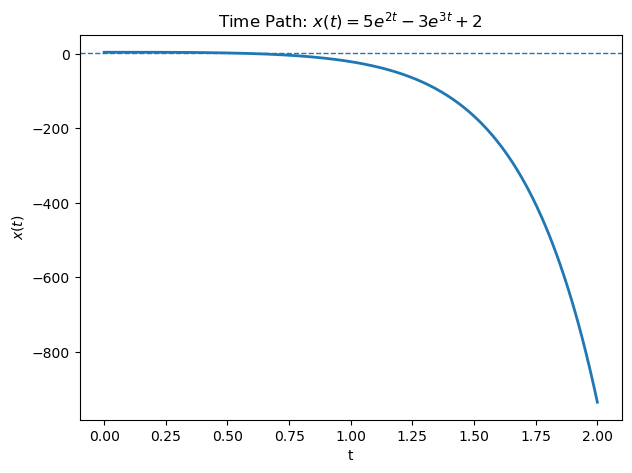

In [18]:
import numpy as np
import matplotlib.pyplot as plt

t = np.linspace(0, 2, 400)
x = 5*np.exp(2*t) - 3*np.exp(3*t) + 2

plt.figure(figsize=(7, 5))
plt.plot(t, x, linewidth=2)
plt.axhline(2, linestyle='--', linewidth=1)
plt.xlabel('t')
plt.ylabel(r'$x(t)$')
plt.title(r'Time Path: $x(t)=5e^{2t}-3e^{3t}+2$')
plt.show()

Since both roots in this example are positive, the path is unstable.

---

## Summary

For a second-order differential equation of the form

:::{math}
:enumerated: false
\ddot{x}(t) + a_1 \dot{x}(t) + a_2 x(t) = b
:::

the steps are:

1. Solve the homogeneous equation to obtain the complementary solution
2. Find a particular solution
3. Add the two together to get the general solution
4. Use two initial conditions to determine the constants
5. Examine the characteristic roots to determine stability

---

## Problems: Differential Equations

### 1. Classification and Stability

For each of the following, determine whether the equation is **homogeneous or nonhomogeneous**, and whether it is **stable or unstable**.

**(a)**  
:::{math}
:enumerated: false
\frac{dx(t)}{dt} = 10x(t) + 5
:::

**(b)**  
:::{math}
:enumerated: false
\dot{x}(t) = -2x(t)
:::

**(c)**  
:::{math}
:enumerated: false
\dot{x}(t) = -\frac{2}{3}x(t) + 2
:::

**(d)**  
:::{math}
:enumerated: false
\frac{dx(t)}{dt} = x(t) - 8
:::

---

### 2. Steady States

For each of the equations above, determine the steady state.

---

### 3. Separation of Variables

Solve the following differential equations:

**(a)**  
:::{math}
:enumerated: false
\frac{dv(t)}{dt} = -v(t)\,t
:::

**(b)**  
:::{math}
:enumerated: false
\frac{dx(t)}{dt} = \frac{x(t)^2}{t}
:::

**(c)**  
:::{math}
:enumerated: false
\frac{dy(t)}{dt} = \frac{-5t}{y(t)}
:::

**(d)**  
:::{math}
:enumerated: false
(t + 5)\,dz(t) - (z(t) + 9)\,dt = 0
:::

---

### 4. Steady States (Second-Order)

Determine the steady state for each of the following:

**(a)**  
:::{math}
:enumerated: false
\ddot{x}(t) = \frac{1}{2}\dot{x}(t) - \frac{2}{3}x(t) + 30
:::

**(b)**  
:::{math}
:enumerated: false
3\ddot{y}(t) - 2\dot{y}(t) + y(t) = 7
:::

---

### 5. Definite Solutions

Find the definite solution for each equation given the initial conditions.

**(a)**  
:::{math}
:enumerated: false
\frac{dx(t)}{dt} = 10x(t) + 5
:::

- $x(0) = -1$  
- $x(0) = 5$

---

**(b)**  
:::{math}
:enumerated: false
\dot{x}(t) = -2x(t)
:::

- $x(0) = 0$  
- $x(0) = 3$

---

**(c)**  
:::{math}
:enumerated: false
\dot{x}(t) = -\frac{2}{3}x(t) + 2
:::

- $x(0) = 0$  
- $x(0) = 3$  
- $x(0) = 5$

---

**(d)**  
:::{math}
:enumerated: false
\frac{dx(t)}{dt} = x(t) - 8
:::

- $x(0) = 4$  
- $x(0) = 8$  
- $x(0) = 12$

---

### 6. Long-Run Behavior

For each solution above, determine:

:::{math}
:enumerated: false
\lim_{t \to \infty} x(t)
:::

In which cases does the limit depend on the initial condition? Explain why.

---

### 7. Characteristic Roots and Stability

Find the characteristic roots and determine stability:

**(a)**  
:::{math}
:enumerated: false
\ddot{x}(t) = -4\dot{x}(t) + \frac{7}{4}x(t) + 5
:::

**(b)**  
:::{math}
:enumerated: false
\ddot{y}(t) = 2\dot{y}(t) + \frac{3}{4}y(t) + 4
:::

**(c)**  
:::{math}
:enumerated: false
\ddot{z}(t) = 2\dot{z}(t) - \frac{5}{4}z(t) + 1
:::

---

## System of Linear Differential Equations

A linear system of two autonomous differential equations may be expressed as

:::{math}
:enumerated: false
\dot{x}(t) = a_{11}x(t) + a_{12}y(t) + b_1
:::

:::{math}
:enumerated: false
\dot{y}(t) = a_{21}x(t) + a_{22}y(t) + b_2
:::

The system must be solved simultaneously because the solution for $x(t)$ depends on the solution for $y(t)$, and the solution for $y(t)$ depends on the solution for $x(t)$.

:::{admonition} Key Idea
:class: note
In a system of differential equations, variables are jointly determined over time. The motion of one variable cannot generally be understood in isolation from the others.
:::

---

## Homogeneous Case

Let us start with a simple example where $b_1=b_2=0$, that is, the homogeneous form of the system:

:::{math}
:enumerated: false
\dot{x}(t) = a_{11}x(t) + a_{12}y(t)
:::

:::{math}
:enumerated: false
\dot{y}(t) = a_{21}x(t) + a_{22}y(t)
:::

By substitution, we may transform the system into a second-order differential equation.

Start with the first equation:

:::{math}
:enumerated: false
\dot{x}(t) = a_{11}x(t) + a_{12}y(t)
:::

Differentiate with respect to time:

:::{math}
:enumerated: false
\ddot{x}(t) = a_{11}\dot{x}(t) + a_{12}\dot{y}(t)
:::

Now use the second equation to substitute for $\dot{y}(t)$:

:::{math}
:enumerated: false
\ddot{x}(t) = a_{11}\dot{x}(t) + a_{12}\big(a_{21}x(t) + a_{22}y(t)\big)
:::

We still need to eliminate $y(t)$. From the first equation,

:::{math}
:enumerated: false
y(t) = \frac{\dot{x}(t) - a_{11}x(t)}{a_{12}}
\qquad \text{assuming } a_{12}\neq 0
:::

Substituting this expression into the previous equation gives a second-order differential equation in $x(t)$ alone. After simplifying and rearranging, we obtain a linear homogeneous second-order differential equation of the form

:::{math}
:enumerated: false
\ddot{x}(t) - (a_{11}+a_{22})\dot{x}(t) + (a_{11}a_{22}-a_{12}a_{21})x(t)=0
:::

This can be written more compactly as

:::{math}
:enumerated: false
\ddot{x}(t) - \operatorname{tr}(A)\dot{x}(t) + |A|x(t)=0
:::

where $\operatorname{tr}(A)$ is the trace of the coefficient matrix and $|A|$ is its determinant.

---

## Three Cases

As with second-order differential equations, there are three possible cases.

### Case 1: Real and distinct roots

If the characteristic roots are real and distinct, then the solution for $x(t)$ is

:::{math}
:enumerated: false
x(t) = A_1 e^{r_1 t} + A_2 e^{r_2 t}
:::

where $r_1$ and $r_2$ are the roots of the characteristic equation

:::{math}
:enumerated: false
r^2 - \operatorname{tr}(A)r + |A| = 0
:::

The corresponding solution for $y(t)$ is then obtained from the first equation,

:::{math}
:enumerated: false
y(t) = \frac{\dot{x}(t) - a_{11}x(t)}{a_{12}}
:::

Differentiate the solution for $x(t)$:

:::{math}
:enumerated: false
\dot{x}(t) = r_1 A_1 e^{r_1 t} + r_2 A_2 e^{r_2 t}
:::

Substituting into the expression for $y(t)$ gives

:::{math}
:enumerated: false
y(t)
=
\frac{(r_1-a_{11})A_1 e^{r_1 t} + (r_2-a_{11})A_2 e^{r_2 t}}{a_{12}}
:::

### Case 2: Real and equal roots

If the characteristic equation has one repeated real root $r$, then the solutions are of the form

:::{math}
:enumerated: false
x(t) = (A_1 + A_2 t)e^{rt}
:::

and

:::{math}
:enumerated: false
y(t) = (B_1 + B_2 t)e^{rt}
:::

where the constants are determined by the system.

### Case 3: Complex roots

If the characteristic roots are complex, the solutions take the oscillatory form

:::{math}
:enumerated: false
x(t)=e^{\alpha t}\left(A_1\cos(\beta t)+A_2\sin(\beta t)\right)
:::

:::{math}
:enumerated: false
y(t)=e^{\alpha t}\left(B_1\cos(\beta t)+B_2\sin(\beta t)\right)
:::

where the roots are $\alpha \pm \beta i$.

:::{admonition} Intuition
:class: note
The system case closely mirrors the second-order scalar case. The main difference is that each root now generates motion in more than one variable.
:::

---

## Numerical Example

Suppose we have the homogeneous system

:::{math}
:enumerated: false
\dot{x}(t) = x(t) + 2y(t)
:::

:::{math}
:enumerated: false
\dot{y}(t) = 3x(t) + 2y(t)
:::

We differentiate the first equation:

:::{math}
:enumerated: false
\ddot{x}(t) = \dot{x}(t) + 2\dot{y}(t)
:::

Using the second equation to substitute for $\dot{y}(t)$ gives

:::{math}
:enumerated: false
\ddot{x}(t) = \dot{x}(t) + 2\big(3x(t)+2y(t)\big)
:::

From the first equation we have

:::{math}
:enumerated: false
y(t)=\frac{\dot{x}(t)-x(t)}{2}
:::

Substituting this into the previous expression gives

:::{math}
:enumerated: false
\ddot{x}(t)=\dot{x}(t)+6x(t)+2\big(\dot{x}(t)-x(t)\big)
:::

Simplifying and rearranging:

:::{math}
:enumerated: false
\ddot{x}(t)-3\dot{x}(t)-4x(t)=0
:::

The characteristic equation is

:::{math}
:enumerated: false
r^2-3r-4=0
:::

with roots

:::{math}
:enumerated: false
r_1=4
\qquad \text{and} \qquad
r_2=-1
:::

These roots are real and distinct, so Case 1 applies. Hence the solution for $x(t)$ is

:::{math}
:enumerated: false
x(t)=A_1 e^{4t}+A_2 e^{-t}
:::

To find the solution for $y(t)$, use

:::{math}
:enumerated: false
y(t)=\frac{\dot{x}(t)-x(t)}{2}
:::

Differentiate $x(t)$:

:::{math}
:enumerated: false
\dot{x}(t)=4A_1 e^{4t}-A_2 e^{-t}
:::

Then

:::{math}
:enumerated: false
y(t)=\frac{4A_1 e^{4t}-A_2 e^{-t}-A_1 e^{4t}-A_2 e^{-t}}{2}
:::

which simplifies to

:::{math}
:enumerated: false
y(t)=\frac{3}{2}A_1 e^{4t}-A_2 e^{-t}
:::

So the general solution is

:::{math}
:enumerated: false
x(t)=A_1 e^{4t}+A_2 e^{-t}
:::

:::{math}
:enumerated: false
y(t)=\frac{3}{2}A_1 e^{4t}-A_2 e^{-t}
:::

---

## Matrix Form

Before proceeding, it is useful to write the system in matrix form.

A linear system of $n$ autonomous differential equations can be expressed as

:::{math}
:enumerated: false
\dot{\mathbf{x}}(t)=A\mathbf{x}(t)+\mathbf{b}
:::

where:

* $A$ is an $(n\times n)$ matrix of constant coefficients
* $\mathbf{b}$ is a vector of constant terms
* $\mathbf{x}(t)$ is the vector of variables
* $\dot{\mathbf{x}}(t)$ is the vector of derivatives

For the example above, we have

:::{math}
:enumerated: false
\begin{bmatrix}
\dot{x}(t) \\
\dot{y}(t)
\end{bmatrix}
=
\begin{bmatrix}
1 & 2 \\
3 & 2
\end{bmatrix}
\begin{bmatrix}
x(t) \\
y(t)
\end{bmatrix}
:::

What is important is the coefficient matrix

:::{math}
:enumerated: false
A =
\begin{bmatrix}
1 & 2 \\
3 & 2
\end{bmatrix}
:::


The characteristic equation is then

:::{math}
:enumerated: false
|A-rI|=0
:::

That is,

:::{math}
:enumerated: false
\begin{vmatrix}
1-r & 2\
3 & 2-r
\end{vmatrix}=0
:::

Expanding the determinant gives

:::{math}
:enumerated: false
(1-r)(2-r)-6=0
:::

or

:::{math}
:enumerated: false
r^2-3r-4=0
:::

which gives, as before,

:::{math}
:enumerated: false
r_1=4
\qquad \text{and} \qquad
r_2=-1
:::

---

## Eigenvectors

For $r_1=4$, the eigenvector is the solution to

:::{math}
:enumerated: false
(A-4I)\mathbf{v}_1=0
:::

which gives

:::{math}
:enumerated: false
\begin{bmatrix}
-3 & 2 \\
3 & -2
\end{bmatrix}
\begin{bmatrix}
v_{11} \\
v_{12}
\end{bmatrix}
=
\begin{bmatrix}
0 \\
0
\end{bmatrix}
:::

This implies

:::{math}
:enumerated: false
-3v_{11}+2v_{12}=0
:::

Letting $v_{11}=2$, we get $v_{12}=3$. Hence one eigenvector is

:::{math}
:enumerated: false
\mathbf{v}_1=
\begin{bmatrix}
2\\
3
\end{bmatrix}
:::

So the first set of solutions is

:::{math}
:enumerated: false
\begin{bmatrix}
x(t) \\
y(t)
\end{bmatrix}
=
A_1
\begin{bmatrix}
2 \\
3
\end{bmatrix}
e^{4t}
:::

For $r_2=-1$, the eigenvector is the solution to

:::{math}
:enumerated: false
(A+I)\mathbf{v}_2=0
:::

that is,

:::{math}
:enumerated: false
\begin{bmatrix}
2 & 2\\
3 & 3
\end{bmatrix}
\begin{bmatrix}
v_{21}\\
v_{22}
\end{bmatrix}
=
\begin{bmatrix}
0\\
0
\end{bmatrix}
:::

This implies

:::{math}
:enumerated: false
v_{21}=-v_{22}
:::

Letting $v_{21}=1$, we get $v_{22}=-1$. Hence one eigenvector is

:::{math}
:enumerated: false
\mathbf{v}_2=
\begin{pmatrix}
1\
-1
\end{pmatrix}
:::

So the second set of solutions is

:::{math}
:enumerated: false
\begin{bmatrix}
x(t)\\
y(t)
\end{bmatrix}
=
A_2
\begin{bmatrix}
1\\
-1
\end{bmatrix}
e^{-t}
:::

Since these two sets of solutions are linearly independent, the general solution is

:::{math}
:enumerated: false
\begin{bmatrix}
x(t)\\
y(t)
\end{bmatrix}
=
A_1
\begin{bmatrix}
2\\
3
\end{bmatrix}
e^{4t}
+
A_2
\begin{bmatrix}
1\\
-1
\end{bmatrix}
e^{-t}
:::

This confirms the solutions obtained by the substitution method.

:::{admonition} Key Idea
:class: note
The matrix method and the substitution method lead to the same solution. The matrix method becomes especially useful in larger systems.
:::

---

## The Particular Solution

We still need to find the particular solution for the nonhomogeneous system

:::{math}
:enumerated: false
\dot{\mathbf{x}}(t)=A\mathbf{x}(t)+\mathbf{b}
:::

The steady state requires that

:::{math}
:enumerated: false
\dot{\mathbf{x}}(t)=0
:::

Hence

:::{math}
:enumerated: false
A\mathbf{x}^*+\mathbf{b}=0
:::

So the particular solution is

:::{math}
:enumerated: false
\mathbf{x}^*=-A^{-1}\mathbf{b}
:::

provided that the inverse matrix exists.

Let us write this out in the case $n=2$:

:::{math}
:enumerated: false
a_{11}x+a_{12}y+b_1=0
:::

:::{math}
:enumerated: false
a_{21}x+a_{22}y+b_2=0
:::

So we have a linear system of two equations in two unknowns.

From the first equation,

:::{math}
:enumerated: false
x=-\frac{a_{12}y+b_1}{a_{11}}
\qquad \text{assuming } a_{11}\neq 0
:::

Substituting this into the second equation gives an expression for $y$, and then substituting back gives an expression for $x$.

In matrix notation, however, the solution is much more compact:

:::{math}
:enumerated: false
\mathbf{x}^*=-A^{-1}\mathbf{b}
:::

This steady state exists if and only if $|A|\neq 0$.

---

## Stability Analysis and Linear Phase Diagrams

The stability of the two-variable system depends on the signs of the two characteristic roots of the matrix $A$, since these roots appear in the exponential terms of the solution.

There are three possible outcomes.

### Type 1: Globally stable

If each of $r_1$ and $r_2$ is negative, then the system is globally stable.

### Type 2: Globally unstable

If each of $r_1$ and $r_2$ is positive, then the system is globally unstable.

### Type 3: Saddle-path stable

If one root is positive and the other is negative, then the system is said to be **saddle-path stable**.

:::{admonition} Intuition
:class: note
In the saddle-path case, there is one stable direction and one unstable direction. Only very special initial conditions place the system on the stable path.
:::

---

## System of Linear Differential Equations II

Let us now look at a slightly different system of differential equations.

First rearrange the equations in matrix form:

:::{math}
:enumerated: false
\dot{\mathbf{x}}(t)=A\mathbf{x}(t)+\mathbf{b}
:::

Suppose

:::{math}
:enumerated: false
A=
\begin{bmatrix}
1 & 2\\
-1 & -2
\end{bmatrix}
\qquad \text{and} \qquad
\mathbf{b}=
\begin{bmatrix}
4\\
1
\end{bmatrix}
:::

The characteristic equation is given by

:::{math}
:enumerated: false
|A-rI|=0
:::

Substituting and dropping subscripts gives

:::{math}
:enumerated: false
\begin{vmatrix}
1-r & 2\\
-1 & -2-r
\end{vmatrix}=0
:::

Expanding:

:::{math}
:enumerated: false
(1-r)(-2-r)+2=0
:::

which simplifies to

:::{math}
:enumerated: false
r^2+r=0
:::

Hence the characteristic roots are

:::{math}
:enumerated: false
r_1=0
\qquad \text{and} \qquad
r_2=-1
:::

Next we find the eigenvectors using

:::{math}
:enumerated: false
(A-rI)\mathbf{v}=0
:::

For $r_1=0$,

:::{math}
:enumerated: false
A\mathbf{v}_1=0
:::

which gives the first elements of the complementary function.

For $r_2=-1$,

:::{math}
:enumerated: false
(A+I)\mathbf{v}_2=0
:::

which gives the second elements of the complementary function.

Combining the two together, the complementary functions are obtained.

To find the particular solution, we solve

:::{math}
:enumerated: false
A\mathbf{x}^*+\mathbf{b}=0
:::

or

:::{math}
:enumerated: false
\mathbf{x}^*=-A^{-1}\mathbf{b}
:::

provided the inverse exists.

Combining the complementary and particular parts gives the complete general solution.

With one root equal to $0$ and the other negative, the system is not asymptotically stable in the usual sense. The zero root indicates a boundary case.

---

## Economic Interpretation

Systems of linear differential equations are used throughout economics because many economic variables interact dynamically.

Examples include:

* inflation and output
* capital and consumption
* debt and interest payments
* price and quantity adjustment
* two-sector growth models

The key lesson is that dynamic stability depends not on one coefficient alone, but on the interaction captured by the eigenvalues of the system matrix.

:::{admonition} Economic Interpretation
:class: tip
In macroeconomics, saddle-path stability is especially important. It appears in models where one variable can jump immediately while another must adjust gradually over time.
:::

---

## Python Figure: A Simple Phase Diagram for a Two-Variable System

Below is a simple vector field for a two-variable linear system.

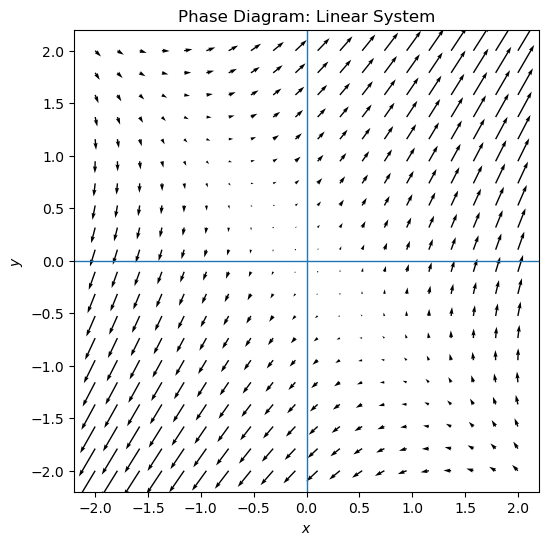

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# Example system
# xdot = x + 2y
# ydot = 3x + 2y

x_vals = np.linspace(-2, 2, 20)
y_vals = np.linspace(-2, 2, 20)
X, Y = np.meshgrid(x_vals, y_vals)

U = X + 2*Y
V = 3*X + 2*Y

plt.figure(figsize=(6, 6))
plt.quiver(X, Y, U, V)
plt.xlabel(r'$x$')
plt.ylabel(r'$y$')
plt.title('Phase Diagram: Linear System')
plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)
plt.show()

This figure gives a qualitative picture of the motion of the system in the $(x,y)$ plane.

---

## Summary

For a system of linear differential equations:

:::{math}
:enumerated: false
\dot{\mathbf{x}}(t)=A\mathbf{x}(t)+\mathbf{b}
:::

the main steps are:

1. find the complementary solution from the characteristic roots and eigenvectors
2. find the particular solution from the steady state condition
3. combine the two to obtain the general solution
4. use initial conditions to determine constants
5. examine the eigenvalues to determine stability
